<a href="https://colab.research.google.com/github/Bhaskar-Manepalli/ML-Academic-Projects/blob/main/RFClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/Mydrive')

Mounted at /content/Mydrive


In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# 1. Load the dataset
data = pd.read_csv('/content/Mydrive/MyDrive/Cancer_Data.csv')

In [ ]:
# 2. Data Preprocessing
# Drop the 'id' column as it holds no predictive value
data = data.drop('id', axis=1)

In [ ]:
# Encode the 'diagnosis' column: M (Malignant) -> 1, B (Benign) -> 0
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

In [ ]:
# Separate features (X) and target (y)
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

In [ ]:
# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
# 5. Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# 6. Make predictions on the test set
y_pred = rf_model.predict(X_test)

In [ ]:
# 7. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:
[[70  1]
 [ 3 40]]


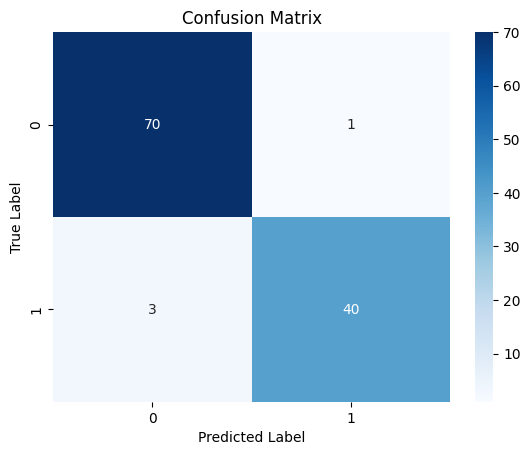

In [ ]:
# 8. Visualize the Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# 9. Display Feature Importances
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10))


Top 10 Most Important Features:
                 Feature  Importance
27  concave points_worst    0.157233
23            area_worst    0.125468
7    concave points_mean    0.121484
22       perimeter_worst    0.118191
20          radius_worst    0.079864
3              area_mean    0.058493
6         concavity_mean    0.047589
0            radius_mean    0.034461
13               area_se    0.034259
2         perimeter_mean    0.028303
